# 02_preprocessing.ipynb

## Multilingual Preprocessing for #FeesMustFall and #EndSARS

**Purpose:** Prepare the standardised audit corpus for language detection, code-switch analysis, emotion modelling, and topic modelling.

This notebook uses **conservative multilingual preprocessing**: remove technical noise, but preserve hashtags, emojis, protest slogans, Nigerian Pidgin, Yoruba, Zulu, and code-switched expressions.


## 1. Imports and Environment Check

In [1]:
import sys
import os
import re
import html
import unicodedata
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    SEABORN_AVAILABLE = True
except ImportError:
    SEABORN_AVAILABLE = False
    print("seaborn not installed; matplotlib fallback will be used.")

try:
    from tqdm.auto import tqdm
    tqdm.pandas()
    TQDM_AVAILABLE = True
except ImportError:
    TQDM_AVAILABLE = False
    print("tqdm not installed; progress bars disabled.")

try:
    import ftfy
    FTFY_AVAILABLE = True
except ImportError:
    FTFY_AVAILABLE = False
    print("ftfy not installed; fallback repairs only.")

warnings.filterwarnings("ignore")

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("pandas version:", pd.__version__)
print("Current working directory:", Path.cwd())

tqdm not installed; progress bars disabled.
ftfy not installed; fallback repairs only.
Python executable: /mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project/venv/bin/python
Python version: 3.12.3 (main, Aug 14 2025, 17:47:21) [GCC 13.3.0]
pandas version: 3.0.3
Current working directory: /mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project


## 2. Project Paths
Configured current WSL/OneDrive project.

In [2]:
PROJECT_DIR = Path("/mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project")

if not PROJECT_DIR.exists():
    print("Primary PROJECT_DIR not found. Falling back to current working directory.")
    PROJECT_DIR = Path.cwd()

OUTPUT_DIR = PROJECT_DIR / "outputs" / "tables"
FIGURE_DIR = PROJECT_DIR / "outputs" / "figures"
LOG_DIR = PROJECT_DIR / "outputs" / "logs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATH = OUTPUT_DIR / "combined_raw_audit_dataset.csv"

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)
print("INPUT_PATH:", INPUT_PATH)
print("Input exists:", INPUT_PATH.exists())

PROJECT_DIR: /mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project
OUTPUT_DIR: /mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project/outputs/tables
FIGURE_DIR: /mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project/outputs/figures
INPUT_PATH: /mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project/outputs/tables/combined_raw_audit_dataset.csv
Input exists: True


## 3. Load Standardised Corpus

In [3]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(f"Could not find {INPUT_PATH}. Run 01_data_audit.ipynb first.")

combined_df = pd.read_csv(INPUT_PATH)

print("Loaded shape:", combined_df.shape)
display(combined_df.head())
print("Columns:", combined_df.columns.tolist())

Loaded shape: (594700, 6)


,movement,tweet_id,date,raw_text,location,existing_language
0,FeesMustFall,5.792884e+17,2015-03-21 14:28:07+00:00,Priorities?? #FeesMustFall RT @informer_sa: UC...,"Braamfontein, South Africa",en
1,FeesMustFall,5.852989e+17,2015-04-07 04:31:56+00:00,#FEESMustFall that will make sense to me. Free...,Nkandla eMagidini,en
2,FeesMustFall,6.539804e+17,2015-10-13 17:07:34+00:00,Now it is time for me to mobilize Wits student...,South Africa,en
3,FeesMustFall,6.539819e+17,2015-10-13 17:13:32+00:00,Residence is going up by over 9% yet I always ...,South Africa,en
4,FeesMustFall,6.539822e+17,2015-10-13 17:14:52+00:00,Tomorrow is D-Day. Sikhathele! #FeesMustFall h...,South Africa,en


Columns: ['movement', 'tweet_id', 'date', 'raw_text', 'location', 'existing_language']


## 4. Validate Required Columns and Baseline Counts

In [4]:
required_columns = ["movement", "tweet_id", "date", "raw_text", "location", "existing_language"]
missing_required = [col for col in required_columns if col not in combined_df.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("All required columns are present.")

baseline_rows = len(combined_df)
baseline_counts = combined_df["movement"].value_counts(dropna=False).reset_index()
baseline_counts.columns = ["movement", "rows_before_preprocessing"]
display(baseline_counts)
print("Baseline rows:", baseline_rows)

All required columns are present.


,movement,rows_before_preprocessing
0,FeesMustFall,462770
1,EndSARS,131930


Baseline rows: 594700


## 5. Initial Preprocessing Diagnostics

In [5]:
combined_df["raw_text"] = combined_df["raw_text"].astype("string")

combined_df["raw_text_length"] = combined_df["raw_text"].fillna("").str.len()
combined_df["raw_word_count"] = combined_df["raw_text"].fillna("").str.split().str.len()
combined_df["raw_has_url"] = combined_df["raw_text"].str.contains(r"http\S+|www\.\S+", regex=True, na=False)
combined_df["raw_has_mention"] = combined_df["raw_text"].str.contains(r"@\w+", regex=True, na=False)
combined_df["raw_has_hashtag"] = combined_df["raw_text"].str.contains(r"#\w+", regex=True, na=False)

initial_diagnostics = combined_df.groupby("movement").agg(
    rows=("raw_text", "count"),
    missing_raw_text=("raw_text", lambda x: x.isna().sum()),
    mean_raw_text_length=("raw_text_length", "mean"),
    median_raw_text_length=("raw_text_length", "median"),
    mean_raw_word_count=("raw_word_count", "mean"),
    median_raw_word_count=("raw_word_count", "median"),
    tweets_with_urls=("raw_has_url", "sum"),
    tweets_with_mentions=("raw_has_mention", "sum"),
    tweets_with_hashtags=("raw_has_hashtag", "sum")
).reset_index()

display(initial_diagnostics)
initial_diagnostics.to_csv(OUTPUT_DIR / "02_initial_preprocessing_diagnostics.csv", index=False)

,movement,rows,missing_raw_text,mean_raw_text_length,median_raw_text_length,mean_raw_word_count,median_raw_word_count,tweets_with_urls,tweets_with_mentions,tweets_with_hashtags
0,EndSARS,131930,0,143.563829,117.0,18.546805,15.0,55736,58533,123126
1,FeesMustFall,462763,7,103.993712,112.0,13.789057,14.0,183556,103623,460805


## 6. Remove Missing Text and Duplicate Tweet IDs

In [6]:
removed_records = []

before = len(combined_df)
missing_text_mask = combined_df["raw_text"].isna() | (combined_df["raw_text"].astype(str).str.strip() == "")
missing_text_removed = combined_df.loc[missing_text_mask].copy()
combined_df = combined_df.loc[~missing_text_mask].copy()
after = len(combined_df)
removed_records.append({"step":"remove_missing_or_empty_raw_text", "rows_before":before, "rows_after":after, "rows_removed":before-after})

before = len(combined_df)
duplicate_mask = combined_df.duplicated(subset=["tweet_id"], keep="first")
duplicate_removed = combined_df.loc[duplicate_mask].copy()
combined_df = combined_df.loc[~duplicate_mask].copy()
after = len(combined_df)
removed_records.append({"step":"remove_duplicate_tweet_ids", "rows_before":before, "rows_after":after, "rows_removed":before-after})

removal_log = pd.DataFrame(removed_records)
display(removal_log)

missing_text_removed.to_csv(OUTPUT_DIR / "02_removed_missing_text_rows.csv", index=False)
duplicate_removed.to_csv(OUTPUT_DIR / "02_removed_duplicate_tweet_ids.csv", index=False)
removal_log.to_csv(OUTPUT_DIR / "02_preprocessing_removal_log.csv", index=False)

print("Shape after missing text and duplicate removal:", combined_df.shape)

,step,rows_before,rows_after,rows_removed
0,remove_missing_or_empty_raw_text,594700,594693,7
1,remove_duplicate_tweet_ids,594693,594612,81


Shape after missing text and duplicate removal: (594612, 11)


## 7. Conservative Multilingual Cleaning Function

In [7]:
COMMON_ENCODING_REPAIRS = {
    "â€¦": "...",
    "â€™": "'",
    "â€˜": "'",
    "â€œ": "\"",
    "â€": "\"",
    "â€“": "-",
    "â€”": "-",
    "Â": "",
    "�": ""
}

def clean_tweet_text(text):
    # Conservative multilingual cleaning.
    # Removes URLs, mentions, standalone RT, HTML/control artefacts and excess whitespace.
    # Preserves hashtags, emojis, casing, punctuation, and multilingual/code-switched content.
    if pd.isna(text):
        return ""

    text = str(text)
    text = html.unescape(text)

    if FTFY_AVAILABLE:
        text = ftfy.fix_text(text)

    for wrong, right in COMMON_ENCODING_REPAIRS.items():
        text = text.replace(wrong, right)

    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\bRT\b", " ", text)

    text = "".join(
        ch for ch in text
        if unicodedata.category(ch)[0] != "C" or ch in ["\n", "\t", " "]
    )

    text = re.sub(r"\s+", " ", text).strip()
    return text

## 8. Apply Cleaning

In [8]:
if TQDM_AVAILABLE:
    combined_df["clean_text"] = combined_df["raw_text"].progress_apply(clean_tweet_text)
else:
    combined_df["clean_text"] = combined_df["raw_text"].apply(clean_tweet_text)

display(combined_df[["movement", "raw_text", "clean_text"]].head(10))

,movement,raw_text,clean_text
0,FeesMustFall,Priorities?? #FeesMustFall RT @informer_sa: UC...,Priorities?? #FeesMustFall : UCT's #RhodesMust...
1,FeesMustFall,#FEESMustFall that will make sense to me. Free...,#FEESMustFall that will make sense to me. Free...
2,FeesMustFall,Now it is time for me to mobilize Wits student...,Now it is time for me to mobilize Wits student...
3,FeesMustFall,Residence is going up by over 9% yet I always ...,Residence is going up by over 9% yet I always ...
4,FeesMustFall,Tomorrow is D-Day. Sikhathele! #FeesMustFall h...,Tomorrow is D-Day. Sikhathele! #FeesMustFall
5,FeesMustFall,NO WE ARE NOT!!! #FEESMustFall https://t.co/TU...,NO WE ARE NOT!!! #FEESMustFall
6,FeesMustFall,If we don't take a stand...Our futures won't b...,If we don't take a stand...Our futures won't b...
7,FeesMustFall,That's why EFF is saying nfsas must fall unive...,That's why EFF is saying nfsas must fall unive...
8,FeesMustFall,Scrap #WitsFeesMustFall #FeesMustFall nje we w...,Scrap #WitsFeesMustFall #FeesMustFall nje we w...
9,FeesMustFall,Current situation at Wits University #AlutaCon...,Current situation at Wits University #AlutaCon...


## 9. Hashtag Extraction

In [9]:
def extract_hashtags(text):
    if pd.isna(text):
        return []
    return re.findall(r"#\w+", str(text).lower())

combined_df["extracted_hashtags"] = combined_df["raw_text"].apply(extract_hashtags)
combined_df["has_hashtag"] = combined_df["extracted_hashtags"].apply(lambda x: len(x) > 0)
combined_df["has_location"] = combined_df["location"].notna()

display(combined_df[["movement", "clean_text", "extracted_hashtags"]].head())

,movement,clean_text,extracted_hashtags
0,FeesMustFall,Priorities?? #FeesMustFall : UCT's #RhodesMust...,"[#feesmustfall, #rhodesmustfall]"
1,FeesMustFall,#FEESMustFall that will make sense to me. Free...,[#feesmustfall]
2,FeesMustFall,Now it is time for me to mobilize Wits student...,[#feesmustfall]
3,FeesMustFall,Residence is going up by over 9% yet I always ...,[#feesmustfall]
4,FeesMustFall,Tomorrow is D-Day. Sikhathele! #FeesMustFall,[#feesmustfall]


## 10. Clean Text Quality Features

In [10]:
combined_df["clean_text"] = combined_df["clean_text"].astype("string")
combined_df["clean_text_length"] = combined_df["clean_text"].fillna("").str.len()
combined_df["word_count"] = combined_df["clean_text"].fillna("").str.split().str.len()
combined_df["unique_word_count"] = combined_df["clean_text"].fillna("").str.split().apply(lambda words: len(set(words)) if isinstance(words, list) else 0)

text_quality_after_cleaning = combined_df.groupby("movement").agg(
    rows=("clean_text", "count"),
    mean_clean_text_length=("clean_text_length", "mean"),
    median_clean_text_length=("clean_text_length", "median"),
    min_clean_text_length=("clean_text_length", "min"),
    max_clean_text_length=("clean_text_length", "max"),
    mean_word_count=("word_count", "mean"),
    median_word_count=("word_count", "median"),
    min_word_count=("word_count", "min"),
    max_word_count=("word_count", "max"),
    tweets_with_hashtags=("has_hashtag", "sum"),
    tweets_with_location=("has_location", "sum")
).reset_index()

display(text_quality_after_cleaning)
text_quality_after_cleaning.to_csv(OUTPUT_DIR / "02_text_quality_after_cleaning.csv", index=False)
display(combined_df[["clean_text_length", "word_count", "unique_word_count"]].describe())

,movement,rows,mean_clean_text_length,median_clean_text_length,min_clean_text_length,max_clean_text_length,mean_word_count,median_word_count,min_word_count,max_word_count,tweets_with_hashtags,tweets_with_location
0,EndSARS,131888,117.818983,91.0,0,1363,17.049390,13.0,0,88,123084,97688
1,FeesMustFall,462724,89.523651,95.0,3,476,13.113716,13.0,1,56,460766,402783


,clean_text_length,word_count,unique_word_count
count,594612.0,594612.000000,594612.000000
mean,95.799701,13.986669,13.216011
std,58.770222,8.887427,7.949387
min,0.0,0.000000,0.000000
25%,59.0,8.000000,8.000000
50%,94.0,13.000000,13.000000
75%,121.0,19.000000,18.000000
max,1363.0,88.000000,53.000000


## 11. Filter Extremely Short Tweets

In [11]:
before = len(combined_df)
short_text_mask = combined_df["word_count"] < 3
short_text_removed = combined_df.loc[short_text_mask].copy()
combined_df = combined_df.loc[~short_text_mask].copy()
after = len(combined_df)

short_text_log = pd.DataFrame([{
    "step": "remove_tweets_with_fewer_than_3_words",
    "rows_before": before,
    "rows_after": after,
    "rows_removed": before - after,
    "removal_percentage_of_step_input": (before - after) / before * 100 if before else 0
}])

display(short_text_log)
short_text_removed.to_csv(OUTPUT_DIR / "02_removed_short_text_rows.csv", index=False)
short_text_log.to_csv(OUTPUT_DIR / "02_short_text_filter_log.csv", index=False)

print("Shape after short-text filtering:", combined_df.shape)
print("Minimum word count:", combined_df["word_count"].min())

,step,rows_before,rows_after,rows_removed,removal_percentage_of_step_input
0,remove_tweets_with_fewer_than_3_words,594612,546246,48366,8.134044


Shape after short-text filtering: (546246, 18)
Minimum word count: 3


## 12. Date Features for Later Protest Phase Analysis

In [12]:
combined_df["date"] = pd.to_datetime(combined_df["date"], errors="coerce", utc=True)
combined_df["year"] = combined_df["date"].dt.year
combined_df["month"] = combined_df["date"].dt.month
combined_df["day"] = combined_df["date"].dt.day
combined_df["year_month"] = combined_df["date"].dt.to_period("M").astype(str)

print("Missing dates after conversion:", combined_df["date"].isna().sum())
display(combined_df[["movement", "date", "year", "month", "day", "year_month"]].head())

Missing dates after conversion: 0


,movement,date,year,month,day,year_month
0,FeesMustFall,2015-03-21 14:28:07+00:00,2015,3,21,2015-03
1,FeesMustFall,2015-04-07 04:31:56+00:00,2015,4,7,2015-04
2,FeesMustFall,2015-10-13 17:07:34+00:00,2015,10,13,2015-10
3,FeesMustFall,2015-10-13 17:13:32+00:00,2015,10,13,2015-10
4,FeesMustFall,2015-10-13 17:14:52+00:00,2015,10,13,2015-10


## 13. Preprocessing Summary

In [13]:
preprocessing_summary = combined_df.groupby("movement").agg(
    rows=("clean_text", "count"),
    mean_clean_text_length=("clean_text_length", "mean"),
    median_clean_text_length=("clean_text_length", "median"),
    min_clean_text_length=("clean_text_length", "min"),
    max_clean_text_length=("clean_text_length", "max"),
    mean_word_count=("word_count", "mean"),
    median_word_count=("word_count", "median"),
    min_word_count=("word_count", "min"),
    max_word_count=("word_count", "max"),
    tweets_with_hashtags=("has_hashtag", "sum"),
    tweets_with_location=("has_location", "sum")
).reset_index()

summary_total = pd.DataFrame([{
    "movement": "TOTAL",
    "rows": len(combined_df),
    "mean_clean_text_length": combined_df["clean_text_length"].mean(),
    "median_clean_text_length": combined_df["clean_text_length"].median(),
    "min_clean_text_length": combined_df["clean_text_length"].min(),
    "max_clean_text_length": combined_df["clean_text_length"].max(),
    "mean_word_count": combined_df["word_count"].mean(),
    "median_word_count": combined_df["word_count"].median(),
    "min_word_count": combined_df["word_count"].min(),
    "max_word_count": combined_df["word_count"].max(),
    "tweets_with_hashtags": combined_df["has_hashtag"].sum(),
    "tweets_with_location": combined_df["has_location"].sum()
}])

preprocessing_summary = pd.concat([preprocessing_summary, summary_total], ignore_index=True)
display(preprocessing_summary)
preprocessing_summary.to_csv(OUTPUT_DIR / "preprocessing_summary.csv", index=False)

,movement,rows,mean_clean_text_length,median_clean_text_length,min_clean_text_length,max_clean_text_length,mean_word_count,median_word_count,min_word_count,max_word_count,tweets_with_hashtags,tweets_with_location
0,EndSARS,109623,139.242102,116.0,7,1363,20.248607,17.0,3,88,102677,81991
1,FeesMustFall,436623,93.743651,98.0,15,386,13.812806,14.0,3,56,434677,380186
2,TOTAL,546246,102.874476,100.0,7,1363,15.104371,14.0,3,88,537354,462177


## 14. Figures

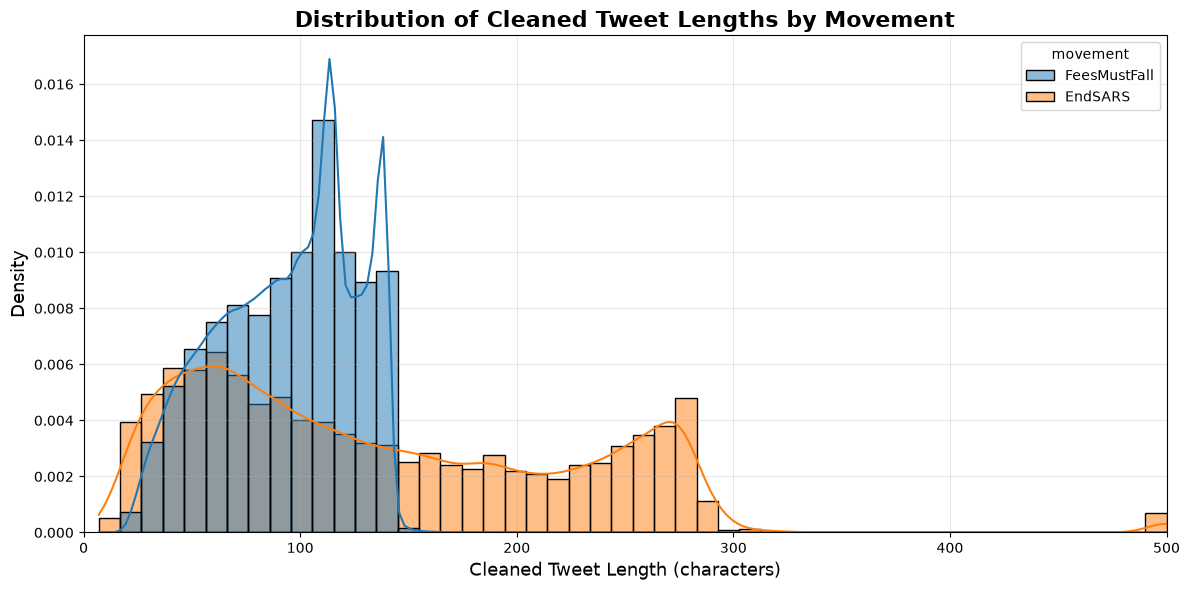

Saved figure: /mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project/outputs/figures/02_clean_text_length_distribution.png


In [14]:
plot_df = combined_df[["movement", "clean_text_length", "word_count"]].copy()
plot_df["clean_text_length_capped"] = plot_df["clean_text_length"].clip(upper=500)

plt.figure(figsize=(12, 6))

if SEABORN_AVAILABLE:
    sns.histplot(data=plot_df, x="clean_text_length_capped", hue="movement", bins=50, kde=True, stat="density", common_norm=False, alpha=0.5)
else:
    for movement, group in plot_df.groupby("movement"):
        plt.hist(group["clean_text_length_capped"], bins=50, alpha=0.5, density=True, label=movement)
    plt.legend()

plt.title("Distribution of Cleaned Tweet Lengths by Movement", fontsize=16, weight="bold")
plt.xlabel("Cleaned Tweet Length (characters)", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.xlim(0, 500)
plt.grid(alpha=0.3)
plt.tight_layout()

fig_path = FIGURE_DIR / "02_clean_text_length_distribution.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved figure:", fig_path)

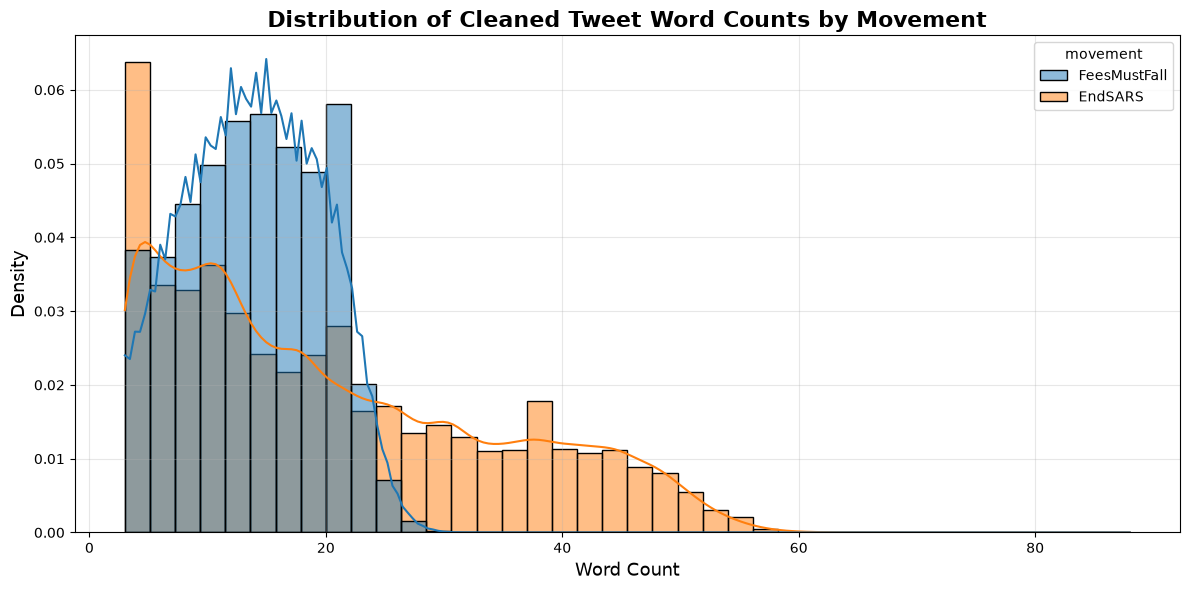

Saved figure: /mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project/outputs/figures/02_word_count_distribution.png


In [15]:
plt.figure(figsize=(12, 6))

if SEABORN_AVAILABLE:
    sns.histplot(data=plot_df, x="word_count", hue="movement", bins=40, kde=True, stat="density", common_norm=False, alpha=0.5)
else:
    for movement, group in plot_df.groupby("movement"):
        plt.hist(group["word_count"], bins=40, alpha=0.5, density=True, label=movement)
    plt.legend()

plt.title("Distribution of Cleaned Tweet Word Counts by Movement", fontsize=16, weight="bold")
plt.xlabel("Word Count", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()

fig_path = FIGURE_DIR / "02_word_count_distribution.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved figure:", fig_path)

## 15. Save Preprocessed Corpus

In [16]:
PREPROCESSED_OUTPUT_PATH = OUTPUT_DIR / "preprocessed_corpus.csv"
combined_df.to_csv(PREPROCESSED_OUTPUT_PATH, index=False, encoding="utf-8")

print("Saved preprocessed corpus to:")
print(PREPROCESSED_OUTPUT_PATH)
print("File exists:", PREPROCESSED_OUTPUT_PATH.exists())
print("Final shape:", combined_df.shape)

Saved preprocessed corpus to:
/mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project/outputs/tables/preprocessed_corpus.csv
File exists: True
Final shape: (546246, 22)


## 16. Final Output Checklist

In [17]:
expected_outputs = [
    OUTPUT_DIR / "02_initial_preprocessing_diagnostics.csv",
    OUTPUT_DIR / "02_removed_missing_text_rows.csv",
    OUTPUT_DIR / "02_removed_duplicate_tweet_ids.csv",
    OUTPUT_DIR / "02_preprocessing_removal_log.csv",
    OUTPUT_DIR / "02_text_quality_after_cleaning.csv",
    OUTPUT_DIR / "02_removed_short_text_rows.csv",
    OUTPUT_DIR / "02_short_text_filter_log.csv",
    OUTPUT_DIR / "preprocessing_summary.csv",
    OUTPUT_DIR / "preprocessed_corpus.csv",
    FIGURE_DIR / "02_clean_text_length_distribution.png",
    FIGURE_DIR / "02_word_count_distribution.png"
]

for path in expected_outputs:
    print(f"{path.name}: {path.exists()}")

print("\nFinal corpus rows:", len(combined_df))
print("Final corpus columns:", len(combined_df.columns))
print("Movement counts:")
print(combined_df["movement"].value_counts())

02_initial_preprocessing_diagnostics.csv: True
02_removed_missing_text_rows.csv: True
02_removed_duplicate_tweet_ids.csv: True
02_preprocessing_removal_log.csv: True
02_text_quality_after_cleaning.csv: True
02_removed_short_text_rows.csv: True
02_short_text_filter_log.csv: True
preprocessing_summary.csv: True
preprocessed_corpus.csv: True
02_clean_text_length_distribution.png: True
02_word_count_distribution.png: True

Final corpus rows: 546246
Final corpus columns: 22
Movement counts:
movement
FeesMustFall    436623
EndSARS         109623
Name: count, dtype: int64


## 17. Notebook Conclusion

The preprocessed corpus is now ready for language detection. The next notebook should create `fasttext_language`, `fasttext_confidence`, `low_confidence_language`, `pidgin_flag`, `yoruba_flag`, `zulu_flag`, `code_switch_flag`, and `final_language_category`.

Do **not** create modelling samples until language detection and code-switch flags are complete.